In [1]:
#a.Load the dataset
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\OMARA\OneDrive\Desktop\Data Analysis and Visualisation-(MSDS-1) Exam Resources-20260425\medical_insurance_dataset.csv")

# Display first few rows
df.head()


,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


In [2]:
#(b) Check for missing/null values

# Check for missing values
df.isnull().sum()

# Inspect data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB


In [3]:
import numpy as np

df.replace("?", np.nan, inplace=True)

# Example: fill categorical with mode
df['smoker'].fillna(df['smoker'].mode()[0], inplace=True)
df['gender'].fillna(df['gender'].mode()[0], inplace=True)

# Verify changes
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2768 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB


C:\Users\OMARA\AppData\Local\Temp\ipykernel_11044\1501607886.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['smoker'].fillna(df['smoker'].mode()[0], inplace=True)
C:\Users\OMARA\AppData\Local\Temp\ipykernel_11044\1501607886.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

In [4]:
#(c) Round charges to two decimal Places
df['charges'] = df['charges'].round(2)
df.head()

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92
1,18,2,33.770,1,0,4,1725.55
2,28,2,33.000,3,0,4,4449.46
3,33,2,22.705,0,0,1,21984.47
4,32,2,28.880,0,0,1,3866.86


In [5]:
#(d) Save the cleaned dataset
df.to_csv("Omara.csv", index=False)

In [ ]:
***(e) Exploratory Visualizations***

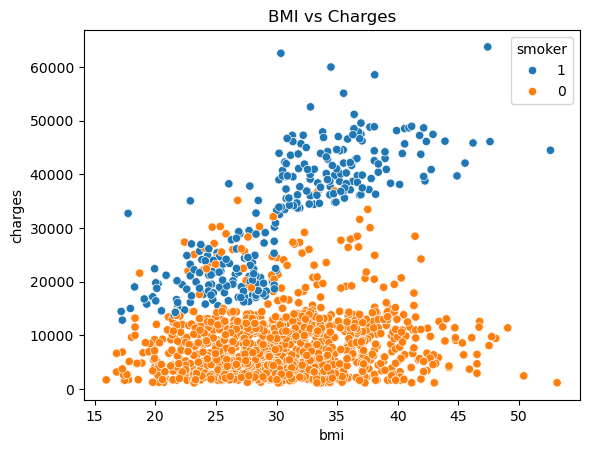

In [6]:
#(e) i) Relationship between BMI and Charges
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="bmi", y="charges", data=df, hue="smoker")
plt.title("BMI vs Charges")
plt.show()


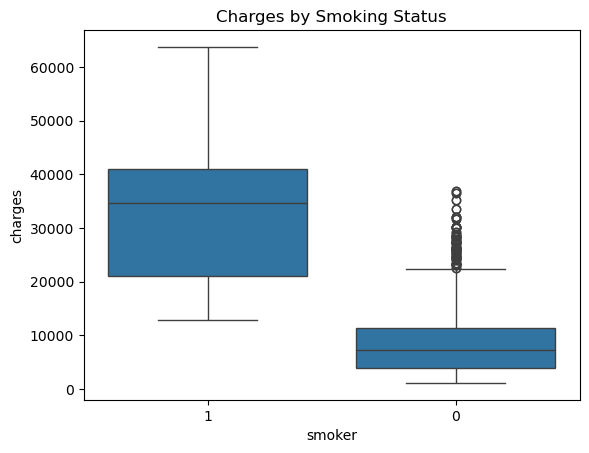

In [7]:
#(e) ii) Compare charges for smokers vs non‑smokers

sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Charges by Smoking Status")
plt.show()


In [ ]:
# (f) Correlation Analysis


In [8]:
# Statistical correlation
corr = df.corr(numeric_only=True)
print(corr['charges'].sort_values(ascending=False))

charges           1.000000
bmi               0.199846
no_of_children    0.066442
gender            0.062837
region            0.054058
Name: charges, dtype: float64


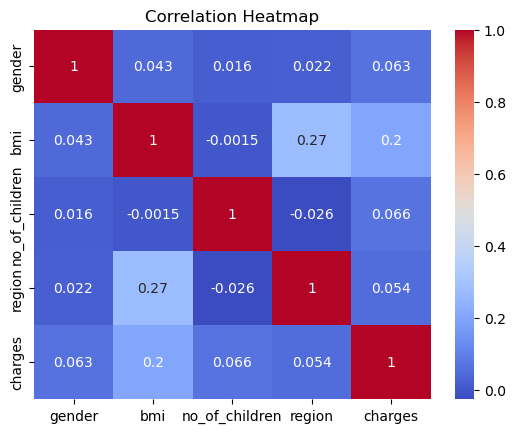

In [9]:
# Visual correlation heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#Stronger relationships:

smoker (binary) has a strong positive effect on charges.

bmi and age also show moderate positive correlations.

no_of_children has weaker influence.

#Summary insights
BMI vs Charges- Charges rise with BMI, especially among smokers.

Smokers vs Non‑Smokers-Smokers incur much higher medical costs.

Correlation-Smoking status, BMI, and age are the most influential predictors of charges.